In [25]:
# ==============================================================================
# Counterfactual Explanations Pipeline (Paper 2) - Complete & Stable Version
# ==============================================================================
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import dice_ml

import os
from pyprojroot import here
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

# ตั้งค่าโฟลเดอร์สำหรับเซฟภาพ
OUT_DIR = 'figures_paper2'
os.makedirs(OUT_DIR, exist_ok=True)

base_path = here()
file_path = os.path.join(base_path, "datas", "SFProgramDataPanal_with_clusters.csv")

df = pd.read_csv(file_path)

In [26]:
# ------------------------------------------------------------------------------
# STEP 1: Data Preparation (อิง Cluster เดิมจาก Paper 1 อย่างสมบูรณ์)
# ------------------------------------------------------------------------------
print("--- STEP 1: Loading Data & Stable Clusters ---")

df = df.replace('.', np.nan)
df_y0 = df[df['Year'] == 0].copy()

CLUSTER_FEATS = [
    'age', 'edu', 'agri_long', 'irriga', 'loan',
    'Avg_ProdManage', 'Avg_InputManage', 'Avg_Tech',
    'Avg_Ana&Plan', 'Avg_Mkting', 'Avg_Network',
    'Ave_ProdRisk', 'Ave_InputRisk', 'Ave_MktRisk', 'Ave_FinRisk'
]

# ดึงเฉพาะคอลัมน์ที่ใช้งานและลบค่าสูญหาย
df_cf = df_y0[['id', 'Cluster'] + CLUSTER_FEATS].apply(pd.to_numeric, errors='coerce').dropna().copy()
X_df = df_cf[CLUSTER_FEATS].copy()
y_df = df_cf['Cluster'].copy()

print(f"Data Loaded: {len(X_df)} records. Clusters Distribution:\n{y_df.value_counts().to_string()}")



--- STEP 1: Loading Data & Stable Clusters ---
Data Loaded: 417 records. Clusters Distribution:
Cluster
0    153
2    145
1    119


In [27]:
# ------------------------------------------------------------------------------
# STEP 2: Train Black-Box Model (RF)
# ------------------------------------------------------------------------------
print("\n--- STEP 2: Training Black-Box Classifier ---")
RF_PARAMS = dict(n_estimators=500, min_samples_leaf=10, max_features='sqrt', random_state=42, n_jobs=-1)
rf_final = RandomForestClassifier(**RF_PARAMS)
rf_final.fit(X_df, y_df)

# ตรวจสอบความแม่นยำเบื้องต้น (Training Acc)
train_acc = accuracy_score(y_df, rf_final.predict(X_df))
print(f"✓ Base Classifier Trained (Accuracy on Full Data: {train_acc:.4f})")


--- STEP 2: Training Black-Box Classifier ---
✓ Base Classifier Trained (Accuracy on Full Data: 0.9640)


In [4]:
# ------------------------------------------------------------------------------
# STEP 3: Setup DiCE (Genetic Method & Monotonic Constraints)
# ------------------------------------------------------------------------------
print("\n--- STEP 3: Initializing DiCE (Genetic) ---")
immutable_feats = ['age', 'edu', 'agri_long']
features_to_vary = [f for f in CLUSTER_FEATS if f not in immutable_feats]

d_data = dice_ml.Data(dataframe=pd.concat([X_df, y_df], axis=1), continuous_features=CLUSTER_FEATS, outcome_name='Cluster')
d_model = dice_ml.Model(model=rf_final, backend="sklearn", model_type="classifier")
# ใช้ Genetic Algorithm ตามคำแนะนำของ Reviewer
exp_dice = dice_ml.Dice(d_data, d_model, method="genetic")

def get_permitted_range(farmer_profile):
    """ สร้างเงื่อนไขห้ามสกิลลดลง และป้องกัน Error ขอบเขตแคบเกินไป """
    ranges = {}
    for feat in features_to_vary:
        val = float(farmer_profile[feat].values[0])
        if 'Avg_' in feat:
            ranges[feat] = [val, val + 0.01] if val >= 5.0 else [val, 5.0]
        else:
            ranges[feat] = [X_df[feat].min(), X_df[feat].max()]
    return ranges




--- STEP 3: Initializing DiCE (Genetic) ---


In [30]:
def process_single_farmer(index, row, source_cluster, target_cluster):
    # 1. รับข้อมูลเกษตรกร 1 คนมาแปลงให้อยู่ในรูปแบบที่ dice_ml อ่านเข้าใจ (DataFrame 1 แถว)
    farmer_profile = pd.DataFrame([row])
    ranges = get_permitted_range(farmer_profile) 
    
    # 2. เตรียม "กระดาษทด" เพื่อรอส่งกลับให้ผู้จัดการ
    # ถ้าหาทางออกไม่ได้ หรือเกิด Error กระดาษใบนี้จะถูกส่งกลับไปแบบว่างๆ (valid: 0)
    result_metric = {'valid': 0, 'sparsity': np.nan, 'l1': np.nan}
    local_action_plans = []
    
    try:
        # ==========================================
        # 3. กระบวนการของ DICE_ML (หาเส้นทางเปลี่ยนกลุ่ม)
        # ==========================================
        cf_res = exp_dice.generate_counterfactuals(
            farmer_profile, 
            total_CFs=5,                  # สั่ง dice ให้หาทางเลือกมา 5 ทาง
            desired_class=target_cluster, # เป้าหมายคือย้ายไป Cluster ที่กำหนด
            features_to_vary=features_to_vary, 
            permitted_range=ranges,
            posthoc_sparsity_param=0.1    # พยายามเปลี่ยนฟีเจอร์ให้น้อยที่สุด
        )
        
        # 4. ตรวจสอบว่า dice_ml สร้างคำตอบมาให้จริงๆ ไหม
        if cf_res and len(cf_res.cf_examples_list) > 0 and cf_res.cf_examples_list[0].final_cfs_df is not None:
            
            orig_df = cf_res.cf_examples_list[0].test_instance_df # ข้อมูลต้นฉบับ
            cfs_df = cf_res.cf_examples_list[0].final_cfs_df      # ทางเลือก 5 ทางที่ dice คิดมาให้
            
            best_sparsity, best_l1, best_cf_row = 999, 999.0, None
            
            # ==========================================
            # 5. กระบวนการคัดเลือกทางเลือกที่ดีที่สุด (จาก 5 ทาง)
            # ==========================================
            # พนักงานจะหยิบทั้ง 5 ทางเลือกมาพิจารณาทีละอัน
            for _, cf_row in cfs_df.iterrows():
                
                # กฎข้อที่ 1: เอาไปถามโมเดลซ้ำว่า "ทางเลือกนี้ย้ายกลุ่มได้จริงไหม?" (Validity)
                is_valid = rf_final.predict(pd.DataFrame([cf_row])[CLUSTER_FEATS])[0] == target_cluster
                if not is_valid: continue # ถ้าไม่จริง ปาทิ้งไปดูทางเลือกอื่น
                    
                changed_feats = 0  # นับว่าต้องเปลี่ยนฟีเจอร์กี่ตัว (Sparsity)
                l1_dist = 0.0      # นับว่าตัวเลขขยับไปไกลแค่ไหน (L1 Distance)
                
                # คำนวณความยากง่ายในการเปลี่ยนกลุ่ม
                for feat in features_to_vary:
                    diff = float(cf_row[feat]) - float(orig_df[feat].values[0])
                    if diff > 0.01: # ตัดเศษทศนิยม (Noise)
                        changed_feats += 1
                        l1_dist += diff
                        
                # กฎข้อที่ 2: ถ้าทางเลือกนี้ "เปลี่ยนฟีเจอร์น้อยกว่า" หรือ "ตัวเลขขยับน้อยกว่า" ให้จดจำทางเลือกนี้ไว้
                if changed_feats < best_sparsity or (changed_feats == best_sparsity and l1_dist < best_l1):
                    best_sparsity = changed_feats
                    best_l1 = l1_dist
                    best_cf_row = cf_row
            
            # ==========================================
            # 6. สร้างหลักสูตร Action Plan จากทางเลือกที่ดีที่สุด
            # ==========================================
            if best_cf_row is not None:
                # บันทึกความสำเร็จลงกระดาษทด
                result_metric = {'valid': 1, 'sparsity': best_sparsity, 'l1': best_l1}
                
                # เทียบข้อมูลเก่ากับใหม่ เพื่อดูว่าต้องให้เกษตรกรเรียนหลักสูตรไหนเพิ่ม
                for feat, course in COURSE_MAPPING.items():
                    diff = float(best_cf_row[feat]) - float(orig_df[feat].values[0])
                    if diff >= 0.1: # ถ้าคะแนนต้องเพิ่มเกิน 0.1 แปลว่าต้องอบรมเรื่องนี้
                        local_action_plans.append({
                            'Farmer_ID': index, 
                            'Path': f'C{source_cluster} -> C{target_cluster}', 
                            'Course': course, 
                            'Increment': diff
                        })
                        
    except Exception as e:
        # ถ้าเครื่อง dice_ml พัง หรือมีตัวแปรไหน Error จะปริ้นท์ฟ้องตรงนี้
        print(f"[Worker Error] เกษตรกร ID {index} พังเพราะ: {e}")
        pass 
    
    # 7. พนักงานยื่นกระดาษทด 2 ใบนี้ กลับไปให้ผู้จัดการ
    return result_metric, local_action_plans

def run_batch_evaluation_parallel(source_cluster, target_cluster, limit=10):
    samples = X_df[y_df == source_cluster]
    if limit: samples = samples.head(limit) 
    
    print(f"Processing Cluster {source_cluster} -> {target_cluster} (Testing {len(samples)} farmers)...")
    start_time = time.time()
    
    # ==========================================
    # 1. สั่งกระจายงาน (จุดกำเนิด Parallel)
    # ==========================================
    # แปลโค้ดบรรทัดนี้: "เฮ้ย CPU ทุกคอร์มารับงาน (n_jobs=-1) ให้ทำฟังก์ชัน process_single_farmer นะ โดยแจกข้อมูลเกษตรกรไปทีละแถว"
    parallel_outputs = Parallel(n_jobs=-1)(
        delayed(process_single_farmer)(index, row, source_cluster, target_cluster) 
        for index, row in samples.iterrows()
    )
    
    # ==========================================
    # 2. รวบรวมงานที่พนักงานส่งคืนมา
    # ==========================================
    # พอ CPU คอร์ต่างๆ ทำงานเสร็จ ตัวแปร parallel_outputs จะหน้าตาเหมือนกระสอบที่ใส่ของมาเป็นคู่ๆ 
    # เช่น [ (metricของคนที่1, planของคนที่1), (metricของคนที่2, planของคนที่2), ... ]
    
    results = []
    action_plans = []
    
    # ผู้จัดการล้วงมือไปหยิบของในกระสอบออกมาทีละคู่ 
    for metric, plans in parallel_outputs:
        results.append(metric)       # เอาสถิติมาเรียงต่อกัน
        action_plans.extend(plans)   # เอาหลักสูตรที่ต้องเรียนมาเรียงต่อกัน (ใช้ extend เพื่อให้ List มันรวมเป็นเส้นเดียว ไม่ซ้อนกัน)
        
    # ==========================================
    # 3. สรุปผลภาพรวม
    # ==========================================
    res_df = pd.DataFrame(results)
    suc_rate = res_df['valid'].mean() * 100
    avg_sp = res_df[res_df['valid'] == 1]['sparsity'].mean()
    avg_l1 = res_df[res_df['valid'] == 1]['l1'].mean()
    exec_t = time.time() - start_time
    
    print(f" ✓ Result: Success {suc_rate:.1f}% | Avg Sparsity: {avg_sp:.2f} | Avg L1: {avg_l1:.2f} | Time: {exec_t:.1f}s")
    
    return action_plans

# สั่งรัน
plans_0_to_1 = run_batch_evaluation_parallel(source_cluster=0, target_cluster=1, limit=None)
plans_1_to_2 = run_batch_evaluation_parallel(source_cluster=1, target_cluster=2, limit=None)
plans_0_to_2 = run_batch_evaluation_parallel(source_cluster=0, target_cluster=2, limit=None)


Processing Cluster 0 -> 1 (Testing 153 farmers)...


100%|██████████| 1/1 [01:31<00:00, 91.70s/it]


 ✓ Result: Success 100.0% | Avg Sparsity: 3.83 | Avg L1: 3.73 | Time: 118.3s
Processing Cluster 1 -> 2 (Testing 119 farmers)...


100%|██████████| 1/1 [01:33<00:00, 93.82s/it]


 ✓ Result: Success 100.0% | Avg Sparsity: 1.72 | Avg L1: 1.88 | Time: 113.1s
Processing Cluster 0 -> 2 (Testing 153 farmers)...


100%|██████████| 1/1 [01:22<00:00, 82.40s/it]


 ✓ Result: Success 100.0% | Avg Sparsity: 2.89 | Avg L1: 2.78 | Time: 134.1s


100%|██████████| 1/1 [01:20<00:00, 80.38s/it]



--- STEP 5: Visualizing Results ---
✓ Visualization saved to: figures_paper2/fig_training_recommendations.png


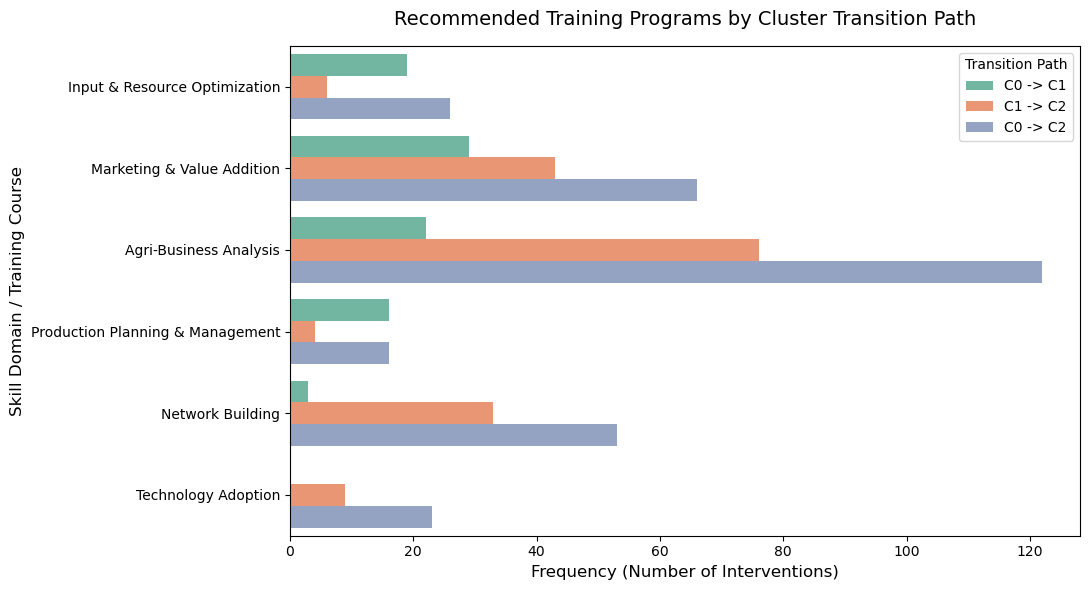

In [31]:
# ------------------------------------------------------------------------------
# STEP 5: Visualizing Global Explanations (Actionability)
# ------------------------------------------------------------------------------
print("\n--- STEP 5: Visualizing Results ---")
all_plans = pd.DataFrame(plans_0_to_1 + plans_1_to_2+ plans_0_to_2)

if not all_plans.empty:
    plt.figure(figsize=(11, 6))
    ax = sns.countplot(data=all_plans, y='Course', hue='Path', palette='Set2')
    
    plt.title('Recommended Training Programs by Cluster Transition Path', fontsize=14, pad=15)
    plt.xlabel('Frequency (Number of Interventions)', fontsize=12)
    plt.ylabel('Skill Domain / Training Course', fontsize=12)
    plt.legend(title='Transition Path')
    plt.tight_layout()
    
    save_path = f"{OUT_DIR}/fig_training_recommendations.png"
    plt.savefig(save_path, dpi=300)
    print(f"✓ Visualization saved to: {save_path}")
    plt.show()
else:
    print("✕ No action plans were generated to visualize.")